In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

import statsmodels.formula.api as smf
from statsmodels.graphics.regressionplots import influence_plot

# Step 1 - Define the problem

In [2]:
East-West Airlines is trying to learn more about its customers.  Key issues are their
flying patterns, earning and use of frequent flyer rewards, and use of the airline credit
card.  The task is to identify customer segments via clustering.





SyntaxError: invalid syntax (3263908970.py, line 1)

# Step 2 - Collect and Prepare Data(EDA)

In [3]:
airline_df=pd.read_csv('EastWestAirlines.csv')

In [4]:
airline_df.head(10)

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
5,6,16420,0,1,1,1,0,0,0,0,6942,0
6,7,84914,0,3,1,1,27482,25,0,0,6994,0
7,8,20856,0,1,1,1,5250,4,250,1,6938,1
8,9,443003,0,3,2,1,1753,43,3850,12,6948,1
9,10,104860,0,3,1,1,28426,28,1150,3,6931,1


In [5]:
airline_df.shape

(3999, 12)

In [6]:
airline_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [7]:
airline_df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [8]:
airline_df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [9]:
- There are no null values

SyntaxError: invalid syntax (3808576816.py, line 1)

### Step 2.1.2 check the distinct values in each column                   

In [10]:
airline_df['Qual_miles'].value_counts()

Qual_miles
0       3773
1000      17
500       15
967        4
888        4
        ... 
1678       1
2954       1
2273       1
739        1
1005       1
Name: count, Length: 164, dtype: int64

In [11]:
airline_df['Qual_miles'].sum()

np.int64(576314)

In [12]:
- 3773 customers did not receive any Qual_miles means customers are not doing much transactins on company portal. 

SyntaxError: invalid syntax (2186990974.py, line 1)

In [13]:
airline_df['cc1_miles'].value_counts().sort_index(ascending=True)

cc1_miles
1    2289
2     284
3     613
4     525
5     288
Name: count, dtype: int64

In [14]:
airline_df[['cc1_miles','Bonus_miles']].sum()

cc1_miles          8236
Bonus_miles    68562240
dtype: int64

In [15]:
airline_df.groupby('cc1_miles')['Bonus_miles'].sum()


cc1_miles
1     9072918
2     3241164
3    12226237
4    21428884
5    22593037
Name: Bonus_miles, dtype: int64

In [16]:
airline_df['cc2_miles'].value_counts().sort_index(ascending=True)

cc2_miles
1    3956
2      28
3      15
Name: count, dtype: int64

In [17]:
airline_df['cc3_miles'].value_counts().sort_index(ascending=True)

cc3_miles
1    3981
2       3
3       4
4       6
5       5
Name: count, dtype: int64

In [18]:
print('no of miles earned by frequent flyer credit card are : ',airline_df['cc1_miles'].sum())
print('no of miles earned by reward credit card are : ',airline_df['cc2_miles'].sum())
print('no of miles earned by small business credit card are : ',airline_df['cc3_miles'].sum())

no of miles earned by frequent flyer credit card are :  8236
no of miles earned by reward credit card are :  4057
no of miles earned by small business credit card are :  4048


- By looking at the above all three features we can say that no of miles earned by frequent flyer credit card are more compare to other 2.
- So we can conclude that frequent flyer credit card is giving morebenefit to the customers

In [19]:
airline_df['Bonus_trans'].value_counts().sort_index(ascending=True)


Bonus_trans
0     475
1     212
2     104
3     250
4     190
5     126
6     115
7      88
8     100
9      91
10     97
11    108
12    148
13    231
14    262
15    212
16    189
17    140
18    125
19     97
20     85
21     69
22     63
23     35
24     41
25     34
26     41
27     32
28     28
29     23
30     17
31     21
32     26
33      8
34     15
35     11
36      6
37     11
38     10
39     12
40      4
41      7
43      7
44      3
45      5
46      2
47      3
49      2
50      3
51      4
52      1
53      4
55      1
58      1
65      2
68      1
86      1
Name: count, dtype: int64

In [20]:
airline_df['Flight_trans_12'].value_counts().sort_index(ascending=True)


Flight_trans_12
0     2723
1      469
2      242
3      132
4       97
5       58
6       43
7       30
8       31
9       32
10      16
11      19
12      16
13       7
14       7
15       9
16      11
17       8
18       8
19       2
20       4
21       1
22       1
23       7
24       4
25       1
26       5
27       1
28       4
29       5
31       1
36       1
45       1
46       1
53       2
Name: count, dtype: int64

- only around 30% of people has bonus transactions

In [21]:
airline_df['Award?'].value_counts()

Award?
0    2518
1    1481
Name: count, dtype: int64

- Almost 60% people did not redeemed their miles towards any reward(free flight, tier updrade,purchasing gift)
- So based on this data company can send some attractive offers to these customers so they can redeem the miles

### Step 2.1.3 Check data types: numerical, categorical, datetime,remove unwanted columns and rows, remove duplicate rows, convert the datatype etc.

In [22]:
airline_df.head(5)

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [23]:
- id is unique identifier we can remove this feature
- change the name of Award

SyntaxError: invalid syntax (2085183992.py, line 1)

In [24]:
airline_df1=airline_df.copy()

In [25]:
airline_df1=airline_df1.drop('ID#',axis=1)

In [26]:
airline_df1=airline_df1.rename(columns={'Award?':'Award'})

In [27]:
airline_df1.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


##  Step 2.3 - Analyze Target Variable – decide the target variable

- there is no target variable

## Step 2.4 - Univariate Analysis (Single Variable) 

- ideally if the customer is old, that customer will have more balance. But by looking at the above graph we can say it not 100% true for this datset

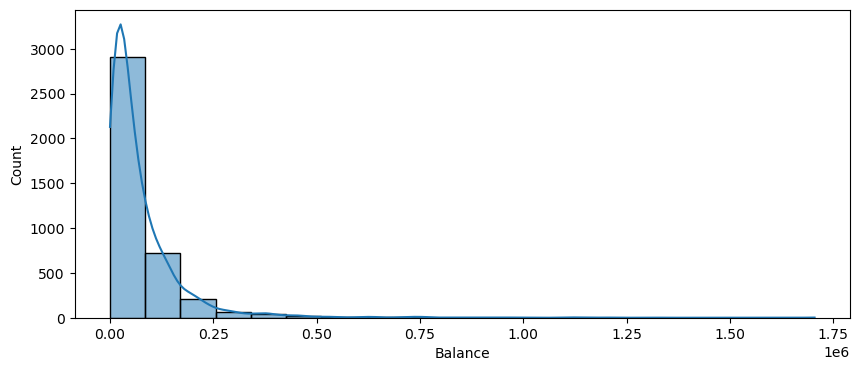

In [28]:
plt.figure(figsize=(10,4))
sns.histplot(airline_df1,x='Balance',kde=True,bins=20)
plt.show()

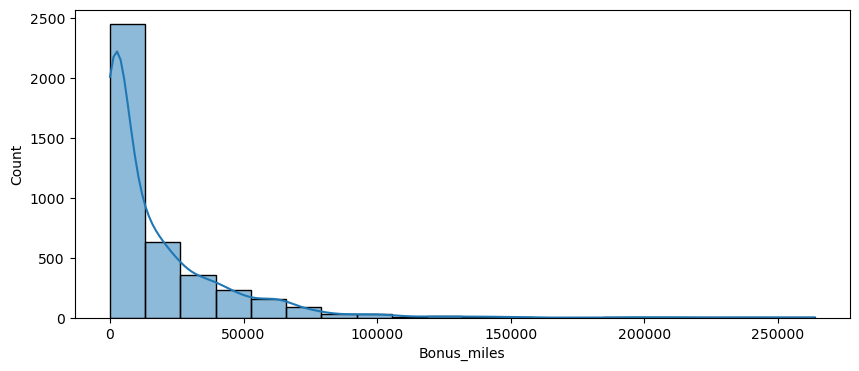

In [29]:
plt.figure(figsize=(10,4))
sns.histplot(airline_df1,x='Bonus_miles',kde=True,bins=20)
plt.show()

- Almost 75% of ciustomers has bonus miles between 0 to 50000

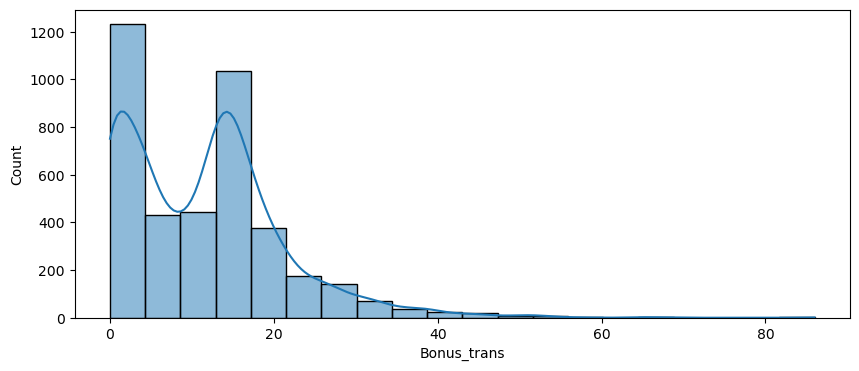

In [30]:
plt.figure(figsize=(10,4))
sns.histplot(airline_df1,x='Bonus_trans',kde=True,bins=20)
plt.show()

<Axes: xlabel='cc3_miles', ylabel='count'>

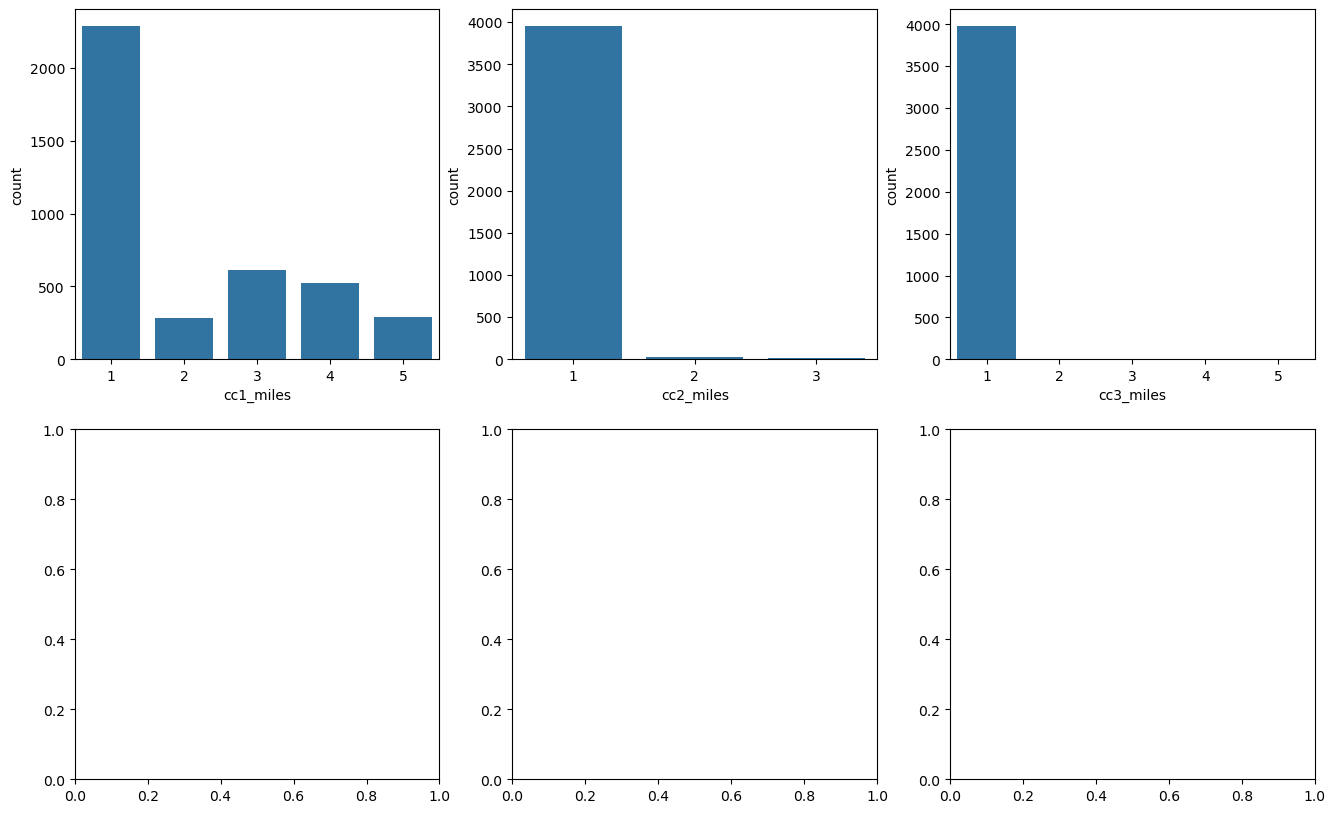

In [31]:
fig, axes = plt.subplots(2,3,figsize=(16,10))
sns.countplot(x='cc1_miles',data=airline_df1,ax=axes[0,0])
sns.countplot(x='cc2_miles',data=airline_df1,ax=axes[0,1])
sns.countplot(x='cc3_miles',data=airline_df1,ax=axes[0,2])

#fig, axes = plt.subplots(2,4, figsize=(16, 10))
#sns.countplot(x='cc1_miles', data=airline_df1,ax=axes[0,0])


##  Step 2.6 - Bivariate/Multivariate Analysis

<Figure size 2000x400 with 0 Axes>

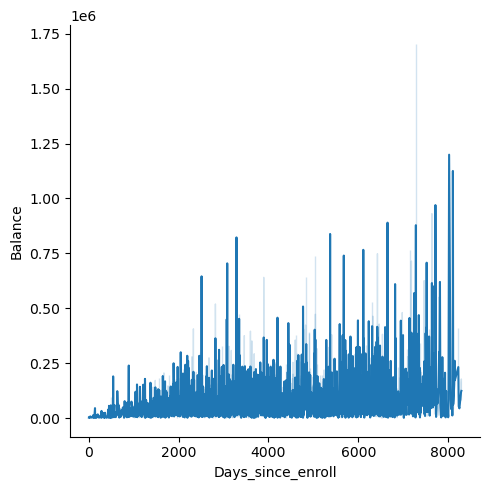

In [32]:
plt.figure(figsize=(20,4))
sns.relplot(airline_df1,x='Days_since_enroll',y='Balance',kind='line')
plt.show()

- BY looking at the above graph we can say thast there are few customers who are maintaning very high alance. May they are not redeeeming it

<Axes: xlabel='cc1_miles', ylabel='Bonus_miles'>

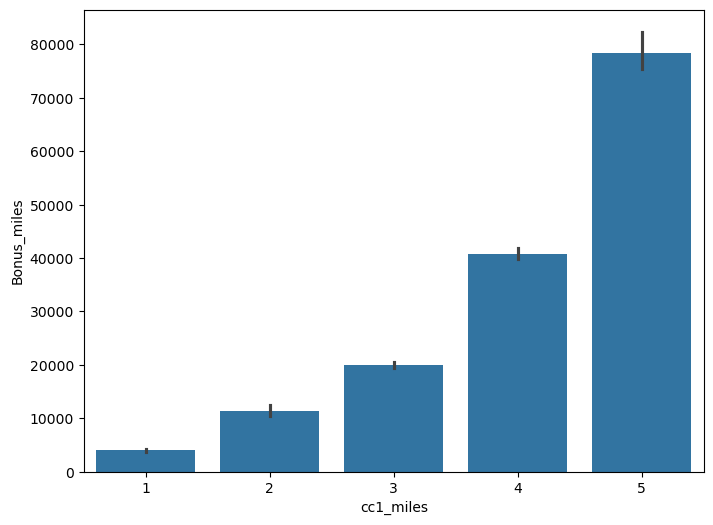

In [33]:
plt.figure(figsize=(8, 6))
sns.barplot(x='cc1_miles', y='Bonus_miles', data=airline_df1, estimator='mean')

<Axes: xlabel='cc3_miles', ylabel='Bonus_miles'>

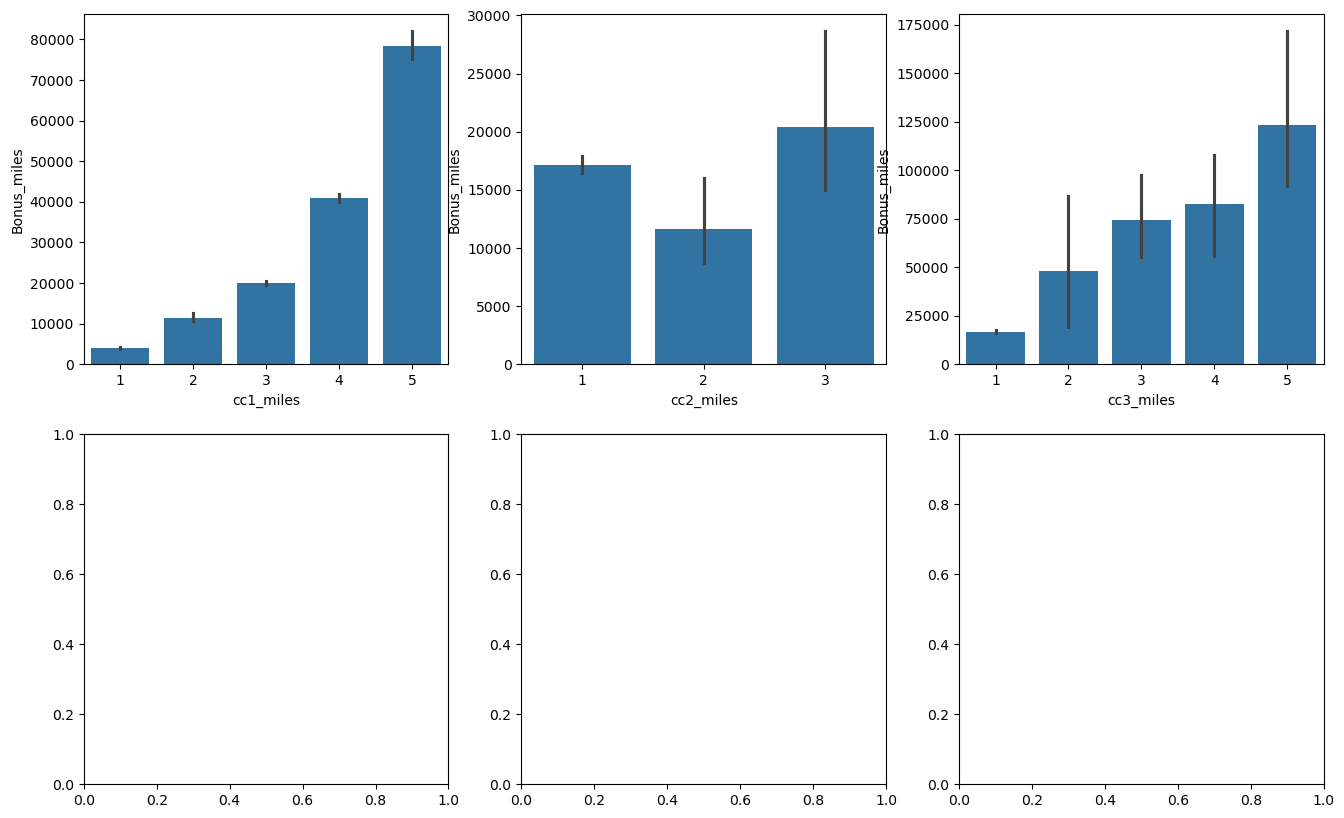

In [34]:
#categorywise bonus
fig, axes = plt.subplots(2,3,figsize=(16,10))
sns.barplot(x='cc1_miles', y='Bonus_miles', data=airline_df1, estimator='mean',ax=axes[0,0])
sns.barplot(x='cc2_miles', y='Bonus_miles', data=airline_df1, estimator='mean',ax=axes[0,1])
sns.barplot(x='cc3_miles', y='Bonus_miles', data=airline_df1, estimator='mean',ax=axes[0,2])


In [35]:
airline_df1_corr=airline_df1.corr()
airline_df1_corr

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
Balance,1.000000,0.108722,0.338344,-0.008804,0.035243,0.403487,0.324935,0.217551,0.255700,0.263129,0.178494
Qual_miles,0.108722,1.000000,0.007931,-0.013923,-0.007779,0.031021,0.050725,0.126774,0.144004,0.017312,0.095256
cc1_miles,0.338344,0.007931,1.000000,-0.068223,0.060555,0.825200,0.608943,0.037370,0.041333,0.230849,0.335457
cc2_miles,-0.008804,-0.013923,-0.068223,1.000000,-0.006166,-0.003969,0.064399,0.010598,0.028284,-0.005807,0.005332
cc3_miles,0.035243,-0.007779,0.060555,-0.006166,1.000000,0.204134,0.097313,-0.001777,-0.001117,0.010832,0.023484
Bonus_miles,0.403487,0.031021,0.825200,-0.003969,0.204134,1.000000,0.603180,0.183536,0.185261,0.210397,0.373506
Bonus_trans,0.324935,0.050725,0.608943,0.064399,0.097313,0.603180,1.000000,0.377216,0.432364,0.161262,0.333893
Flight_miles_12mo,0.217551,0.126774,0.037370,0.010598,-0.001777,0.183536,0.377216,1.000000,0.869193,0.037271,0.217715
Flight_trans_12,0.255700,0.144004,0.041333,0.028284,-0.001117,0.185261,0.432364,0.869193,1.000000,0.059260,0.247909
Days_since_enroll,0.263129,0.017312,0.230849,-0.005807,0.010832,0.210397,0.161262,0.037271,0.059260,1.000000,0.188121


In [36]:
(airline_df1_corr>0.6) & (airline_df1_corr<1)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
Balance,False,False,False,False,False,False,False,False,False,False,False
Qual_miles,False,False,False,False,False,False,False,False,False,False,False
cc1_miles,False,False,False,False,False,True,True,False,False,False,False
cc2_miles,False,False,False,False,False,False,False,False,False,False,False
cc3_miles,False,False,False,False,False,False,False,False,False,False,False
Bonus_miles,False,False,True,False,False,False,True,False,False,False,False
Bonus_trans,False,False,True,False,False,True,False,False,False,False,False
Flight_miles_12mo,False,False,False,False,False,False,False,False,True,False,False
Flight_trans_12,False,False,False,False,False,False,False,True,False,False,False
Days_since_enroll,False,False,False,False,False,False,False,False,False,False,False


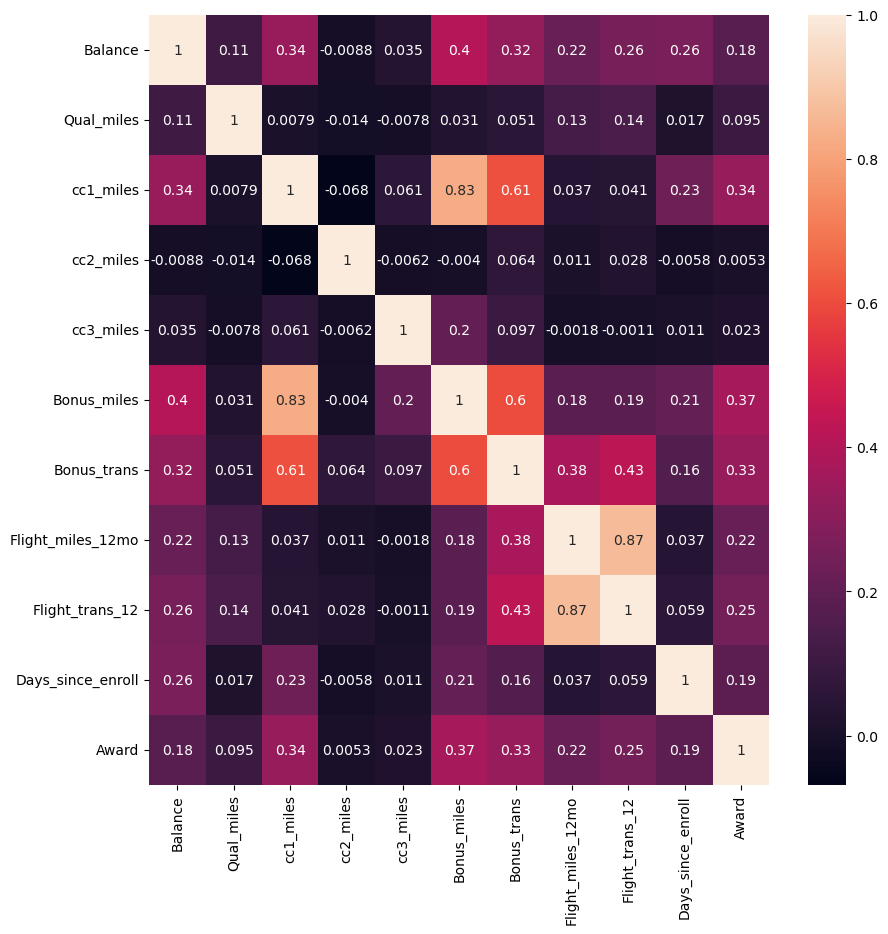

In [37]:
plt.figure(figsize=(10,10))
sns.heatmap(airline_df1_corr,annot=True)
plt.show()

- By looking at the heatmap we can say that below features are highly corelated with each other
- Bonus_miles - CC1_miles - Means may be the transactions are happening through flyer credit card getting bonus
- flight_miles_2_mo - Flight_trans_12

## Step 2.7 – Encoding the values

- No encoding is required as all the features are already in number

##  Step 2.8 - Outlier Detection

<Axes: ylabel='Flight_trans_12'>

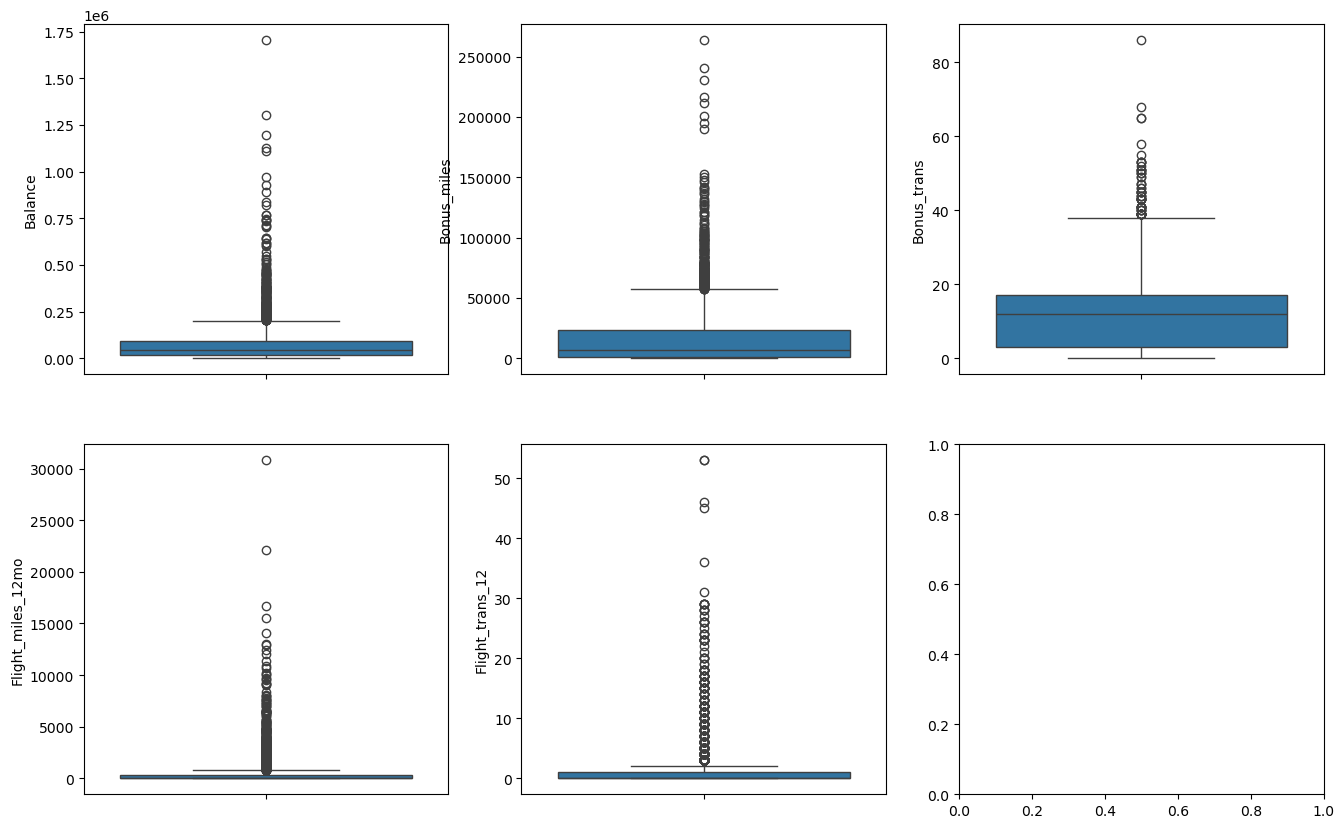

In [38]:
fig, axes=plt.subplots(2,3,  figsize=(16,10))
# sns.catplot(data=airline_df1,y='Balance',ax=axes[0,1],kind='box') - sns will not support ax=axes[0,1]
sns.boxplot(data=airline_df1,y='Balance',ax=axes[0,0])
sns.boxplot(data=airline_df1,y='Bonus_miles',ax=axes[0,1])
sns.boxplot(data=airline_df1,y='Bonus_trans',ax=axes[0,2])
sns.boxplot(data=airline_df1,y='Flight_miles_12mo',ax=axes[1,0])
sns.boxplot(data=airline_df1,y='Flight_trans_12',ax=axes[1,1])

# K-means clustering

# Step 3 - Split the Data

- Not actaully neede here as we dont have target variable to compare

##  Step 3.1 - find out independent and dependent variable

In [39]:
- Not actaully neede here as we dont have target variable to compare

SyntaxError: invalid syntax (24604715.py, line 1)

### 3.2.1 Scaling the model

In [40]:
from sklearn.preprocessing import StandardScaler
std_sclr=StandardScaler()
std_sclr.fit(airline_df1)

airline_df1_scaled=std_sclr.transform(airline_df1)

In [41]:
# Convert scaled array back to DataFrame with original column names
airline_df1_scaled_df=pd.DataFrame(airline_df1_scaled,columns=airline_df1.columns) 
airline_df1_scaled_df


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
0,-0.451141,-0.186299,-0.769578,-0.098242,-0.062767,-0.702786,-1.104065,-0.328603,-0.362168,1.395454,-0.766919
1,-0.539457,-0.186299,-0.769578,-0.098242,-0.062767,-0.701088,-0.999926,-0.328603,-0.362168,1.379957,-0.766919
2,-0.320031,-0.186299,-0.769578,-0.098242,-0.062767,-0.539253,-0.791649,-0.328603,-0.362168,1.411920,-0.766919
3,-0.583799,-0.186299,-0.769578,-0.098242,-0.062767,-0.689286,-1.104065,-0.328603,-0.362168,1.372208,-0.766919
4,0.239678,-0.186299,1.409471,-0.098242,-0.062767,1.083121,1.499394,1.154932,0.692490,1.363975,1.303918
...,...,...,...,...,...,...,...,...,...,...,...
3994,-0.547079,-0.186299,-0.769578,-0.098242,-0.062767,-0.356960,-0.791649,-0.185750,-0.098503,-1.315120,1.303918
3995,-0.091465,-0.186299,-0.769578,-0.098242,-0.062767,-0.669367,-0.687511,-0.328603,-0.362168,-1.318994,1.303918
3996,-0.000043,-0.186299,0.683121,-0.098242,-0.062767,0.343804,-0.375096,-0.328603,-0.362168,-1.315604,1.303918
3997,-0.185607,-0.186299,-0.769578,-0.098242,-0.062767,-0.689286,-1.104065,0.028531,-0.098503,-1.316088,-0.766919


In [42]:
# as data is not normally distiributed better to use minmaxscaler
from sklearn.preprocessing import MinMaxScaler
MinMax_sclr=MinMaxScaler()
MinMax_sclr.fit(airline_df1)

airline_df1_scaled1=MinMax_sclr.transform(airline_df1)

In [43]:
airline_df1_scaled_df1=pd.DataFrame(airline_df1_scaled1,columns=airline_df1.columns) 
airline_df1_scaled_df1

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
0,0.016508,0.0,0.00,0.0,0.0,0.000660,0.011628,0.000000,0.000000,0.843742,0.0
1,0.011288,0.0,0.00,0.0,0.0,0.000815,0.023256,0.000000,0.000000,0.839884,0.0
2,0.024257,0.0,0.00,0.0,0.0,0.015636,0.046512,0.000000,0.000000,0.847842,0.0
3,0.008667,0.0,0.00,0.0,0.0,0.001896,0.011628,0.000000,0.000000,0.837955,0.0
4,0.057338,0.0,0.75,0.0,0.0,0.164211,0.302326,0.067398,0.075472,0.835905,1.0
...,...,...,...,...,...,...,...,...,...,...,...
3994,0.010837,0.0,0.00,0.0,0.0,0.032330,0.046512,0.006490,0.018868,0.168917,1.0
3995,0.037766,0.0,0.00,0.0,0.0,0.003720,0.058140,0.000000,0.000000,0.167953,1.0
3996,0.043169,0.0,0.50,0.0,0.0,0.096505,0.093023,0.000000,0.000000,0.168797,1.0
3997,0.032202,0.0,0.00,0.0,0.0,0.001896,0.011628,0.016225,0.018868,0.168676,0.0


# Step 5 - Choose the Algorithm and Build the model

In [44]:
from sklearn.cluster import KMeans
KMeans_ini=KMeans(n_clusters=4,random_state=42) #initialize
KMeans_model=KMeans_ini.fit(airline_df1_scaled) # airline_df1_scaled - should scalled data, we can not pass dataframe here

C:\Users\Dell\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Dell\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Dell\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Dell\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^

In [45]:
KMeans_model.labels_
# KMeans_ini.labels_ - both can be used as internally both are pointing to same object

array([2, 2, 2, ..., 3, 3, 3], dtype=int32)

In [46]:

#(KMeans_model.labels__).unique() - this will not work as .uniqu will work with pandas not with arrays.
import numpy as np

np.unique(KMeans_model.labels_)

array([0, 1, 2, 3], dtype=int32)

In [47]:
KMeans_ini.inertia_

28909.479400430573

In [48]:
airline_df2=airline_df1.copy()# whilw calucaltiong silhout score we need use original dataset not paaded dataset with labe feature
airline_df2.head() 

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


In [49]:
airline_df2['labels']=KMeans_model.labels_

In [50]:
airline_df2.head(5)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award,labels
0,28143,0,1,1,1,174,1,0,0,7000,0,2
1,19244,0,1,1,1,215,2,0,0,6968,0,2
2,41354,0,1,1,1,4123,4,0,0,7034,0,2
3,14776,0,1,1,1,500,1,0,0,6952,0,2
4,97752,0,4,1,1,43300,26,2077,4,6935,1,1


In [51]:
airline_df1.head(5)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


## Step 7.1 - Evaluate the Model by using silhouette_score

In [52]:
from sklearn.metrics import silhouette_score
silhouette_score(airline_df1,KMeans_model.labels_)

np.float64(-0.03043427078135077)

- As silhot score near to minus values the model is not coorect

### Step 7.1.1 lets build the elbow method to get the correct k value

In [53]:
wcss=[]
for k in range(1,11):
    model1 = KMeans(n_clusters=k)
    model1.fit(airline_df1_scaled)
    wcss.append(model1.inertia_)


In [54]:
wcss

[43989.0,
 35409.61927448697,
 31013.6721079615,
 28589.20585898689,
 26999.685045732782,
 23971.1272354216,
 23807.289244082065,
 17371.641431879136,
 16067.840490809076,
 16091.722923769741]

In [55]:
wcss_dict={}
for k in range(1,11):
    model1 = KMeans(n_clusters=k)
    model1.fit(airline_df1_scaled)
    wcss_dict.update({k:model1.inertia_})



In [56]:
wcss_dict

{1: 43989.0,
 2: 35409.51662986131,
 3: 30900.41304706546,
 4: 29065.67743313718,
 5: 25855.660174167435,
 6: 24722.915157141266,
 7: 19880.872914986783,
 8: 18619.59195524439,
 9: 16070.065168165605,
 10: 14732.229882347436}

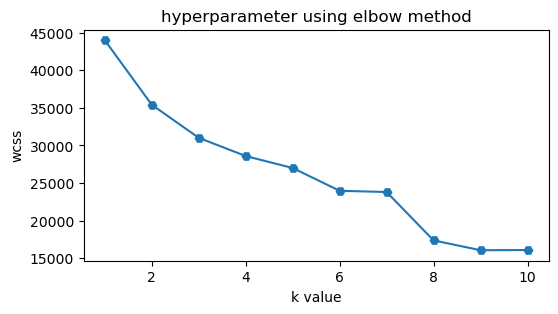

In [57]:
# lets plot
plt.figure(figsize=(6,3))
plt.plot(range(1,11),wcss,marker='H')
plt.title('hyperparameter using elbow method')
plt.xlabel('k value')
plt.ylabel('wcss')
plt.show()

In [58]:
wcss_dict1={}
for k in range(1,21):
    model2 = KMeans(n_clusters=k)
    model2.fit(airline_df1_scaled)
    wcss_dict1.update({k:model2.inertia_})

In [59]:
wcss_dict1

{1: 43989.0,
 2: 35409.61927448697,
 3: 30906.161177016424,
 4: 29397.39682590637,
 5: 24885.833053896455,
 6: 22087.873594024113,
 7: 22284.152652490793,
 8: 22131.80881650978,
 9: 16537.71283491978,
 10: 15240.637751032988,
 11: 14561.877049189306,
 12: 12947.121495609646,
 13: 13121.55430288235,
 14: 12255.578177583846,
 15: 11627.692648777132,
 16: 11169.49656644256,
 17: 10794.363834909498,
 18: 10520.673637017811,
 19: 10464.197564154885,
 20: 10045.741933394813}

In [60]:
wcss3=[]
for k in range(1,21):
    model3 = KMeans(n_clusters=k)
    model3.fit(airline_df1_scaled)
    wcss3.append(model3.inertia_)


In [61]:
wcss3

[43989.0,
 35409.61927448697,
 31013.6721079615,
 27155.072973055863,
 24884.11534043499,
 24094.444676137213,
 22041.080813011657,
 17505.411778878755,
 16534.144252969993,
 14726.983322766791,
 13705.15424134504,
 13818.313817209477,
 12710.173825415592,
 12023.218668394518,
 11660.380483062567,
 11317.884916979308,
 11138.97910665015,
 10509.490305060051,
 10222.215860181353,
 9879.241508308713]

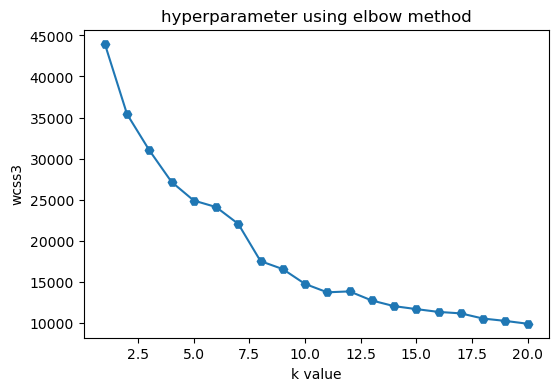

In [62]:
# lets plot
plt.figure(figsize=(6,4))
plt.plot(range(1,21),wcss3,marker='H')
plt.title('hyperparameter using elbow method')
plt.xlabel('k value')
plt.ylabel('wcss3')
plt.show()

In [63]:
wcss_dict3={}
for k in range(1,21):
    model4 = KMeans(n_clusters=k)
    model4.fit(airline_df1_scaled)
    wcss_dict3.update({k:model4.inertia_})

In [64]:
wcss_dict3

{1: 43989.0,
 2: 35409.51662986131,
 3: 31013.6721079615,
 4: 29393.09855442355,
 5: 23700.398440609617,
 6: 21756.926621337145,
 7: 19502.47695102843,
 8: 18907.695249323973,
 9: 16050.695368874825,
 10: 15246.181729119851,
 11: 13708.007941837242,
 12: 13573.58277650164,
 13: 12876.519235840933,
 14: 12141.787254099178,
 15: 11568.869979039308,
 16: 11450.613480134783,
 17: 10768.958646170553,
 18: 10718.96025081625,
 19: 10597.522650319052,
 20: 10059.353848189145}

In [65]:
silhouette_score(airline_df1,model3.labels_)

np.float64(-0.1573803077502838)

## Step 8 - Analysis fter model creation 

In [66]:
airline_df1.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


In [67]:
type(airline_df1)

pandas.core.frame.DataFrame

In [68]:
airline_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Balance            3999 non-null   int64
 1   Qual_miles         3999 non-null   int64
 2   cc1_miles          3999 non-null   int64
 3   cc2_miles          3999 non-null   int64
 4   cc3_miles          3999 non-null   int64
 5   Bonus_miles        3999 non-null   int64
 6   Bonus_trans        3999 non-null   int64
 7   Flight_miles_12mo  3999 non-null   int64
 8   Flight_trans_12    3999 non-null   int64
 9   Days_since_enroll  3999 non-null   int64
 10  Award              3999 non-null   int64
dtypes: int64(11)
memory usage: 343.8 KB


In [69]:
airline_df2['labels'].value_counts()



labels
3    1502
2    1236
1    1105
0     156
Name: count, dtype: int64

In [70]:
agg=airline_df2.groupby('labels')
agg.mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
labels,,,,,,,,,,,
0,193291.147436,795.455128,2.179487,1.038462,1.000000,32292.288462,27.628205,5530.230769,16.211538,4688.070513,0.820513
1,122119.899548,151.724887,3.885068,1.002715,1.043439,43772.394570,19.398190,366.520362,1.087783,4777.394570,0.687783
2,59693.586570,112.733010,1.372168,1.031553,1.000809,6311.116505,8.456311,258.830097,0.806634,5744.810680,0.296117
3,36920.458056,96.690413,1.269640,1.006658,1.000000,4897.208389,6.790280,167.861518,0.509321,2236.466711,0.151132


In [125]:
kmeans_pca = PCA(n_components=2)
kmeans_2D = Hir_pca.fit_transform(airline_df1_scaled)

In [128]:
kmeans_2D

array([[-1.46667427, -0.06718286],
       [-1.4505642 , -0.06374317],
       [-1.2100507 , -0.13355511],
       ...,
       [ 0.17353576, -0.61180929],
       [-1.69524058,  0.72653107],
       [-2.10886559,  0.40309321]])

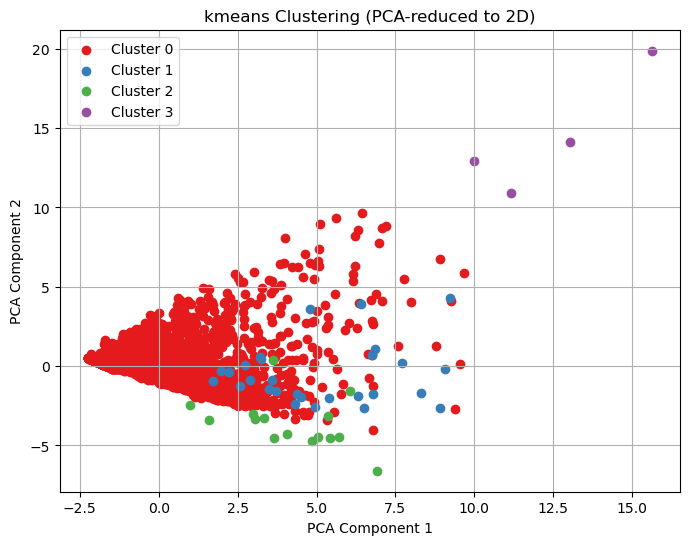

In [129]:
keans_unique_labels = np.unique(KMeans_model.labels_)
plt.figure(figsize=(8, 6))
for idx, label in enumerate(keans_unique_labels):
    mask = (Aug_clust_model.labels_ == label)
    color = 'black' if label == -1 else plt.cm.Set1(idx)
    label_name = 'Noise' if label == -1 else f'Cluster {label}'
    plt.scatter(kmeans_2D[mask, 0], kmeans_2D[mask, 1], c=[color], label=label_name)

plt.title("kmeans Clustering (PCA-reduced to 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.show()

# Hirarical clustering

In [73]:
from sklearn.cluster import AgglomerativeClustering

In [75]:
Aug_clust=AgglomerativeClustering(n_clusters=4,linkage='complete',metric='euclidean')
Aug_clust_model=Aug_clust.fit(airline_df1_scaled)


In [76]:
Aug_clust_model.labels_

array([0, 0, 0, ..., 0, 0, 0])

In [77]:
np.unique(Aug_clust_model.labels_)

array([0, 1, 2, 3])

In [ ]:
# np.unique(Aug_clust_model.innertia_) - this is available only for kemeans

In [84]:
from sklearn.metrics import silhouette_score

hiraricval_score = silhouette_score(airline_df1, Aug_clust_model.labels_)
print("Silhouette Score:", hiraricval_score)

Silhouette Score: 0.4221701998671745


In [78]:
airline_df1.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


In [80]:
airline_df1_hirarical=airline_df1.copy()

In [81]:
airline_df1_hirarical['label']=Aug_clust_model.labels_

In [82]:
airline_df1_hirarical.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award,label
0,28143,0,1,1,1,174,1,0,0,7000,0,0
1,19244,0,1,1,1,215,2,0,0,6968,0,0
2,41354,0,1,1,1,4123,4,0,0,7034,0,0
3,14776,0,1,1,1,500,1,0,0,6952,0,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1,0


In [124]:
airline_df1_hirarical['label'].value_counts()

label
0    3952
1      28
2      15
3       4
Name: count, dtype: int64

In [88]:
label_agg=airline_df1_hirarical.groupby('label')
label_agg.mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
label,,,,,,,,,,,
0,68105.429656,142.463057,2.043016,1.014676,1.000759,16511.953441,11.412955,433.876518,1.294281,4099.368674,0.365638
1,806433.285714,383.214286,3.571429,1.000000,1.000000,58412.321429,21.214286,1344.392857,5.607143,6835.892857,0.857143
2,138061.400000,78.800000,3.466667,1.000000,4.066667,93927.866667,28.066667,506.666667,1.600000,4613.866667,0.533333
3,131999.500000,347.000000,2.500000,1.000000,1.000000,65634.250000,69.250000,19960.000000,49.250000,2200.250000,1.000000


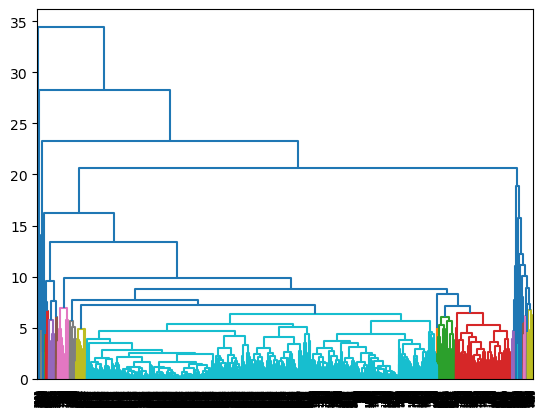

In [87]:
from scipy.cluster import hierarchy
hr=hierarchy.linkage(airline_df1_scaled,method='complete')
dn=hierarchy.dendrogram(hr,color_threshold=7)

In [121]:
from sklearn.decomposition import PCA
Hir_pca = PCA(n_components=2)
hir_2D = Hir_pca.fit_transform(airline_df1_scaled)

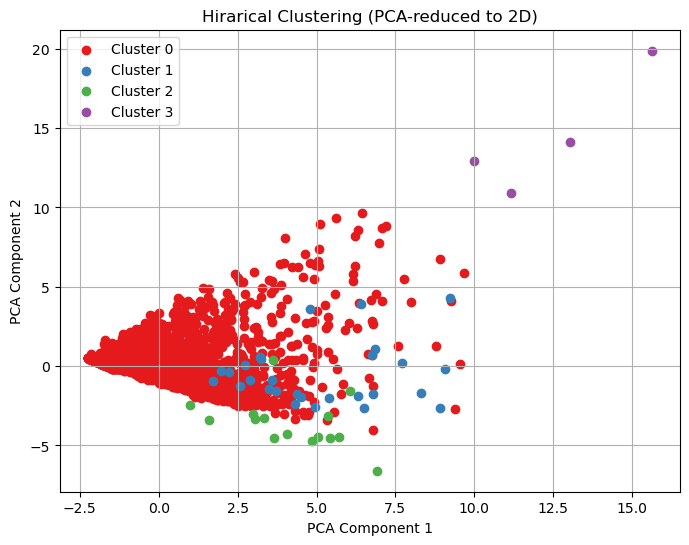

In [122]:
unique_labels = np.unique(Aug_clust_model.labels_)
plt.figure(figsize=(8, 6))
for idx, label in enumerate(unique_labels):
    mask = (Aug_clust_model.labels_ == label)
    color = 'black' if label == -1 else plt.cm.Set1(idx)
    label_name = 'Noise' if label == -1 else f'Cluster {label}'
    plt.scatter(hir_2D[mask, 0], hir_2D[mask, 1], c=[color], label=label_name)

plt.title("Hirarical Clustering (PCA-reduced to 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.show()

# DB scan

In [103]:
from sklearn.cluster import DBSCAN
DBSCAN_init=DBSCAN(min_samples=22,eps=0.5)
db_scan_model=DBSCAN_init.fit(airline_df1_scaled)

In [104]:
db_scan_model.labels_

array([ 0,  0,  0, ..., -1,  0,  0])

In [105]:
np.unique(db_scan_model.labels_)

array([-1,  0,  1,  2,  3,  4])

In [106]:
DBSCAN_airline_df1=airline_df1.copy()

In [107]:
DBSCAN_airline_df1['label']=db_scan_model.labels_

In [108]:
DBSCAN_airline_df1.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award,label
0,28143,0,1,1,1,174,1,0,0,7000,0,0
1,19244,0,1,1,1,215,2,0,0,6968,0,0
2,41354,0,1,1,1,4123,4,0,0,7034,0,0
3,14776,0,1,1,1,500,1,0,0,6952,0,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1,-1


In [110]:
DBscan_silhout=silhouette_score(airline_df1,db_scan_model.labels_)
print(DBscan_silhout)

-0.28407513373682935


In [ ]:
- As i have more than one fetures in X, so we can not visualze directly with scatterplot. Need to use dimension reduction techniques.

In [116]:
from sklearn.decomposition import PCA
DBscan_pca = PCA(n_components=2)
DBscan_2D = DBscan_pca.fit_transform(airline_df1_scaled)

In [117]:
DBscan_2D

array([[-1.46667427, -0.06718286],
       [-1.4505642 , -0.06374317],
       [-1.2100507 , -0.13355511],
       ...,
       [ 0.17353576, -0.61180929],
       [-1.69524058,  0.72653107],
       [-2.10886559,  0.40309321]])

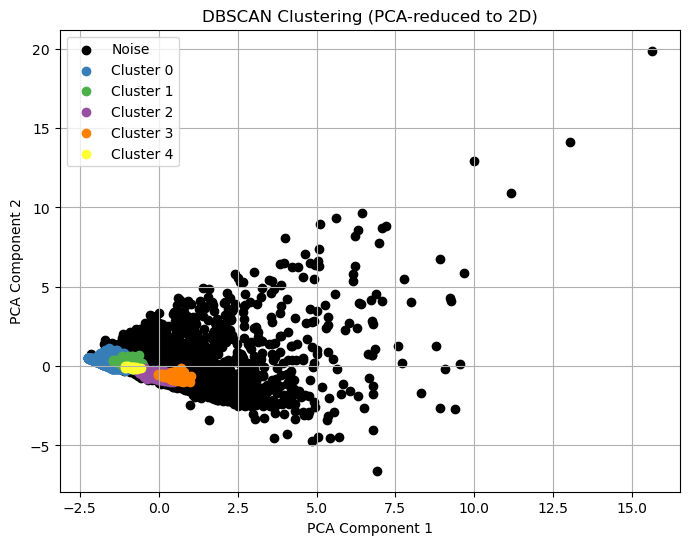

In [120]:

unique_labels = np.unique(db_scan_model.labels_)
plt.figure(figsize=(8, 6))
for idx, label in enumerate(unique_labels):
    mask = (db_scan_model.labels_ == label)
    color = 'black' if label == -1 else plt.cm.Set1(idx)
    label_name = 'Noise' if label == -1 else f'Cluster {label}'
    plt.scatter(DBscan_2D[mask, 0], DBscan_2D[mask, 1], c=[color], label=label_name)

plt.title("DBSCAN Clustering (PCA-reduced to 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.show()

# conlusion 
###  - EDA analysis
####   --3773 customers did not receive any Qual_miles means customers are not doing much transactins on company portal.
####   --By looking at the above all three features we can say that no of miles earned by frequent flyer credit card are more compare to other 2.
####   --So we can conclude that frequent flyer credit card is giving morebenefit to the customers
####   --Almost 60% people did not redeemed their miles towards any reward(free flight, tier updrade,purchasing gift)
####   --So based on this data company can send some attractive offers to these customers so they can redeem the miles
####   --BY looking at the above graph we can say thast there are few customers who are maintaning very high alance. May they are not redeeeming it
####   --By looking at the heatmap we can say that below features are highly corelated with each other
####   --Bonus_miles - CC1_miles - Means may be the transactions are happening through flyer credit card getting bonus
####   --flight_miles_2_mo - Flight_trans_12

# Kmeans model
### -By looking at the WCSS and slhout score we can say that kmeans model is not performing well on this dataset

# Hirarical model
### Hirarical model is performed awell with given dataset as silhout score is better of hirarical model

# DBscan model
### Silhout score of dbscan is -0.28. the DBscan model is not performing good
